# Topstep ML Pipeline - Interactive Analysis

This notebook provides an interactive way to:
- Explore data and features
- Train models with visualization
- Analyze backtest results
- Experiment with different configurations

**Note:** The pipeline was updated to (1) clean corrupted bars, (2) align labels with next-bar execution, and (3) evaluate via trade-identical backtests. Re-run the notebook top-to-bottom to regenerate plots/metrics.


In [1]:
# Setup
import sys
from pathlib import Path

# Add project root to path if not already installed as package
project_root = Path().resolve().parent if Path().resolve().name == 'analysis' else Path().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, JSON

# Project imports
from core.simple_config import TRAINING_CONFIG
from data.prepare_dataset import prepare_training_data
from models.train import load_bars, train_models
from backtesting.backtest import run_backtest
from features.engineer import add_features, select_features

# Configure plotting
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('default')

sns.set_palette('husl')
%matplotlib inline


## 1. Load and Explore Data


In [2]:
# Load data (or prepare if needed)
# Ensure we're in the project root for relative paths
import os
project_root = Path().resolve().parent if Path().resolve().name == 'analysis' else Path().resolve()
os.chdir(project_root)

data_path = "data/processed/mes_bars.h5"

if not Path(data_path).exists():
    print("Preparing dataset...")
    # Use the actual CSV file that exists
    csv_path = "data/raw/MES_2010_2025_OHLCV_1m.csv"
    prepare_training_data(csv_path=csv_path, output_path=data_path)
else:
    print(f"Using existing processed data at {data_path}")

bars = load_bars(data_path)
print(f"Loaded {len(bars):,} bars")
print(f"Date range: {bars['timestamp'].min()} to {bars['timestamp'].max()}")

# Show sample
display(bars.head(10))


Using existing processed data at data/processed/mes_bars.h5

BAR CLEANING REPORT
Input rows:  130,150
Output rows: 130,021  (removed 129)
 - non-finite rows:            0
 - invalid OHLC rows:          0
 - extreme log-return rows:    0
 - extreme range rows:         0
 - outside close quantiles:    129

Loaded 130,021 bars
Date range: 2019-05-06 13:30:00+00:00 to 2025-12-02 20:55:00+00:00


,timestamp,open,high,low,close,volume
0,2019-05-06 13:30:00+00:00,2898.00,2898.50,2894.00,2898.00,1258
1,2019-05-06 13:35:00+00:00,2898.25,2908.50,2898.25,2908.00,6501
2,2019-05-06 13:40:00+00:00,2907.75,2911.25,2906.50,2910.25,3095
3,2019-05-06 13:45:00+00:00,2910.25,2911.50,2909.25,2911.00,2001
4,2019-05-06 13:50:00+00:00,2911.00,2911.00,2905.25,2906.00,2255
5,2019-05-06 13:55:00+00:00,2905.75,2911.75,2905.50,2910.50,2435
6,2019-05-06 14:00:00+00:00,2910.50,2914.50,2910.50,2912.25,2827
7,2019-05-06 14:05:00+00:00,2912.25,2912.25,2909.50,2910.75,3056
8,2019-05-06 14:10:00+00:00,2911.00,2914.00,2911.00,2913.25,4660
9,2019-05-06 14:15:00+00:00,2913.25,2916.50,2913.25,2914.50,3049


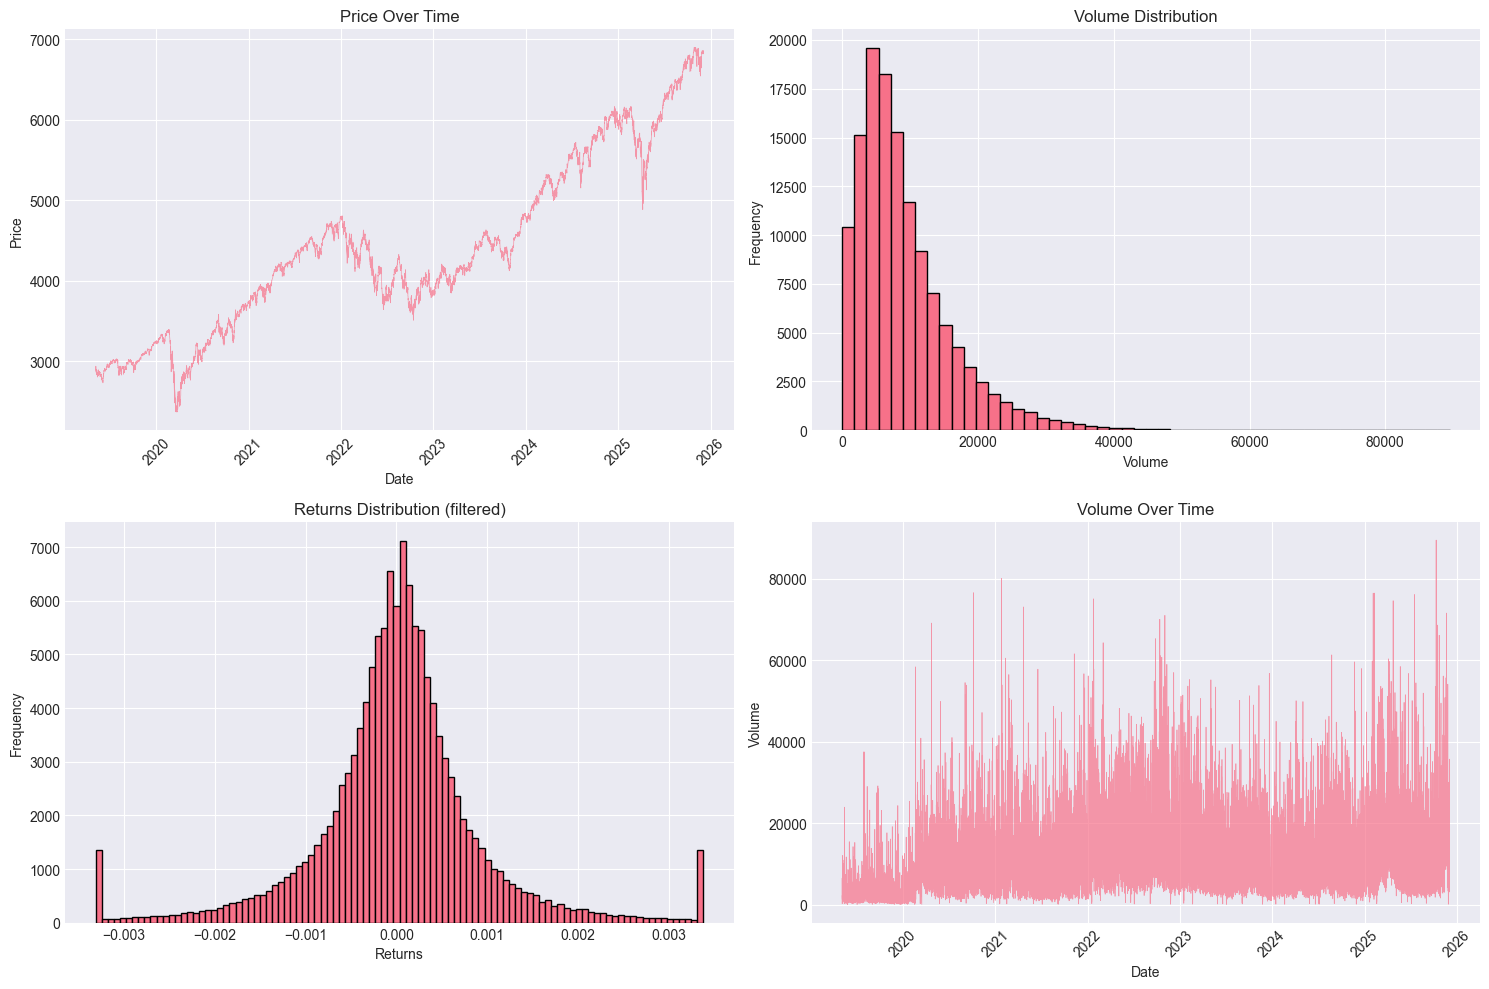

In [3]:
# Basic statistics and visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Price over time
axes[0, 0].plot(bars['timestamp'], bars['close'], alpha=0.7, linewidth=0.5)
axes[0, 0].set_title('Price Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price')
axes[0, 0].tick_params(axis='x', rotation=45)

# Volume distribution
axes[0, 1].hist(bars['volume'], bins=50, edgecolor='black')
axes[0, 1].set_title('Volume Distribution')
axes[0, 1].set_xlabel('Volume')
axes[0, 1].set_ylabel('Frequency')

# Returns distribution (filter out inf and NaN values)
returns = bars['close'].pct_change().dropna()
returns_clean = returns[np.isfinite(returns)]  # Remove inf and NaN
if len(returns_clean) > 0:
    # Clip extreme outliers for better visualization
    q1, q99 = returns_clean.quantile([0.01, 0.99])
    returns_clean = returns_clean.clip(q1, q99)
    axes[1, 0].hist(returns_clean, bins=100, edgecolor='black')
    axes[1, 0].set_title('Returns Distribution (filtered)')
    axes[1, 0].set_xlabel('Returns')
    axes[1, 0].set_ylabel('Frequency')
else:
    axes[1, 0].text(0.5, 0.5, 'No valid returns data', 
                     ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Returns Distribution')

# Volume over time
axes[1, 1].plot(bars['timestamp'], bars['volume'], alpha=0.7, linewidth=0.5)
axes[1, 1].set_title('Volume Over Time')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Volume')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 2. Feature Engineering


In [4]:
# Add features (use subset for faster exploration)
sample_bars = bars.tail(10000).reset_index(drop=True)  # Last 10k bars
features_df = add_features(sample_bars, verbose=True)

print(f"\nFeature columns: {len([c for c in features_df.columns if c not in ['timestamp', 'open', 'high', 'low', 'close', 'volume']])}")
display(features_df.describe())



FEATURE ENGINEERING

[1/7] Price features...
[2/7] Trend features...
[3/7] Volatility features...
[4/7] Volume features...
[5/7] Time features...
[6/7] Market structure features...
[7/7] Risk-aware features...

OK: feature engineering complete
  Total features: 52

Feature columns: 52


,open,high,low,close,volume,returns_1,returns_5,returns_12,log_returns_1,body,...,high_50,low_50,range_position_12,range_position_50,dist_from_high_12,dist_from_low_12,estimated_stop_ticks,estimated_risk_usd,trade_affordable,max_contracts_by_risk
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9999.000000,9995.000000,9988.000000,9999.000000,10000.000000,...,9951.000000,9951.000000,9989.000000,9951.000000,9989.000000,9989.000000,9987.000000,9987.000000,10000.000000,10000.000000
mean,6489.580925,6492.502875,6486.519700,6489.583875,10662.017800,0.000015,0.000075,0.000181,0.000015,2.941700,...,6514.048035,6461.686966,0.561444,0.596396,0.001596,0.001999,22.519922,28.149903,0.998700,4.994800
std,267.873498,268.052275,267.706641,267.816577,7802.220831,0.000869,0.001956,0.003034,0.000869,3.268672,...,267.739708,264.470071,0.300047,0.308535,0.002022,0.002192,3.010301,3.762876,0.036034,0.144135
min,5859.000000,5864.000000,5853.000000,5859.250000,89.000000,-0.014577,-0.016868,-0.020682,-0.014684,0.000000,...,5915.500000,5853.000000,0.000000,0.000000,0.000000,0.000000,8.000000,10.000000,0.000000,1.000000
25%,6310.750000,6312.250000,6308.750000,6311.187500,5218.000000,-0.000293,-0.000617,-0.000953,-0.000293,1.000000,...,6335.500000,6288.500000,0.294118,0.316984,0.000405,0.000701,22.928571,28.660714,1.000000,5.000000
50%,6480.250000,6482.500000,6478.500000,6480.250000,8392.000000,0.000037,0.000078,0.000218,0.000037,2.000000,...,6496.250000,6462.750000,0.600000,0.654206,0.000934,0.001352,24.000000,30.000000,1.000000,5.000000
75%,6723.000000,6726.750000,6720.000000,6723.000000,13888.500000,0.000328,0.000773,0.001298,0.000328,3.750000,...,6756.750000,6690.500000,0.834532,0.889340,0.001988,0.002477,24.000000,30.000000,1.000000,5.000000
max,6910.250000,6915.000000,6896.750000,6897.750000,89476.000000,0.017210,0.019220,0.022152,0.017064,58.250000,...,6915.000000,6883.250000,1.000000,1.000000,0.022078,0.022119,24.000000,30.000000,1.000000,5.000000


## 3. Model Training & Backtest


In [5]:
# Train models (use subset for faster iteration)
# Use a single bar window for this notebook run so training, tuning, and backtest are consistent.
experiment_bars = bars.tail(50000).reset_index(drop=True)  # Adjust size as needed

# Optional: override parameters for this notebook run
TRAINING_CONFIG.label_mode = 'per_bar'        # 'per_bar' or 'sequential'
TRAINING_CONFIG.stop_loss_ticks = 32
TRAINING_CONFIG.target_multiplier = 2.0
TRAINING_CONFIG.max_hold_bars = 12

print('Notebook training config:')
display(JSON({
    'label_mode': TRAINING_CONFIG.label_mode,
    'stop_loss_ticks': TRAINING_CONFIG.stop_loss_ticks,
    'target_multiplier': TRAINING_CONFIG.target_multiplier,
    'max_hold_bars': TRAINING_CONFIG.max_hold_bars,
}, indent=2))

print('Training models (this may take several minutes)...')
results = train_models(experiment_bars)

print('Tuned policy (selected on validation via trade-identical backtest):')
display(JSON(results.get('policy', {}), indent=2))

print('Classification + label-trade stats (train/val/test):')
display(JSON(results.get('metrics', {}), indent=2))

print('Trade-identical backtest summaries by split (KPI):')
summaries = {}
for split_name, split_res in (results.get('backtest_metrics') or {}).items():
    summaries[split_name] = (split_res or {}).get('summary', {})
display(JSON(summaries, indent=2))


Notebook training config:


<IPython.core.display.JSON object>

Training models (this may take several minutes)...

FEATURE ENGINEERING

[1/7] Price features...
[2/7] Trend features...
[3/7] Volatility features...
[4/7] Volume features...
[5/7] Time features...
[6/7] Market structure features...
[7/7] Risk-aware features...

OK: feature engineering complete
  Total features: 52
Tuned policy (selected on validation via trade-identical backtest):


<IPython.core.display.JSON object>

Classification + label-trade stats (train/val/test):


<IPython.core.display.JSON object>

Trade-identical backtest summaries by split (KPI):


<IPython.core.display.JSON object>

In [7]:
# Run backtest using the tuned policy (including gating)
policy = results.get('policy', {})

print('Running backtest (this may take a few minutes)...')
backtest = run_backtest(
    experiment_bars,
    results['long_model'],
    results['short_model'],
    results['feature_cols'],
    save_trades_path='analysis/notebook_backtest_trades.csv',
    min_probability_long=policy.get('min_probability_long'),
    min_probability_short=policy.get('min_probability_short'),
    enable_long=policy.get('enable_long'),
    enable_short=policy.get('enable_short'),
    blocked_hours=policy.get('blocked_hours'),
    allowed_hours=policy.get('allowed_hours'),
    exclude_lunch=policy.get('exclude_lunch'),
    require_trend_long=policy.get('require_trend_long'),
    require_trend_short=policy.get('require_trend_short'),
    min_atr_ticks=policy.get('min_atr_ticks'),
    max_atr_ticks=policy.get('max_atr_ticks'),
    stop_loss_ticks=TRAINING_CONFIG.stop_loss_ticks,
    target_multiplier=TRAINING_CONFIG.target_multiplier,
    max_hold_bars=TRAINING_CONFIG.max_hold_bars,
    slippage_ticks=1,
    commission_per_contract=2.35,
)

print('Backtest Summary:')
display(JSON(backtest['summary'], indent=2))


Running backtest (this may take a few minutes)...
Backtest Summary:


<IPython.core.display.JSON object>

## 4. Monte Carlo Analysis

Monte Carlo simulation bootstraps trade outcomes to assess strategy robustness and potential performance distributions.


In [8]:
# Import Monte Carlo simulator
from analysis.monte_carlo_simulator import MonteCarloSimulator

# Run Monte Carlo simulation on backtest trades
initial_equity = backtest["summary"]["starting_balance"]
simulator = MonteCarloSimulator(backtest["trades"], initial_equity, seed=42)

print("Running Monte Carlo simulation (500 runs)...")
mc_result = simulator.run(runs=500, sample_size=None)  # Use same number of trades as baseline

print("\nMonte Carlo Results:")
display(JSON(mc_result["summary"], indent=2))


Running Monte Carlo simulation (500 runs)...

Monte Carlo Results:


<IPython.core.display.JSON object>

**Note on Monte Carlo Method:**

The Monte Carlo simulation now uses **block bootstrap** by default, which properly handles time-series data. Unlike simple bootstrap (which randomly samples individual trades), block bootstrap preserves temporal structure by sampling blocks of consecutive trades. This is critical for:

1. **Proper drawdown analysis** - Consecutive losses are preserved
2. **Risk management accuracy** - Daily loss limits and trailing drawdown depend on trade sequence
3. **Realistic equity curves** - Temporal dependencies in trade outcomes are maintained

Block size is automatically calculated as `sqrt(n_trades)` (bounded between 5-20 trades) to optimize the balance between preserving structure and allowing sufficient variability.


KeyError: 'raw_results'

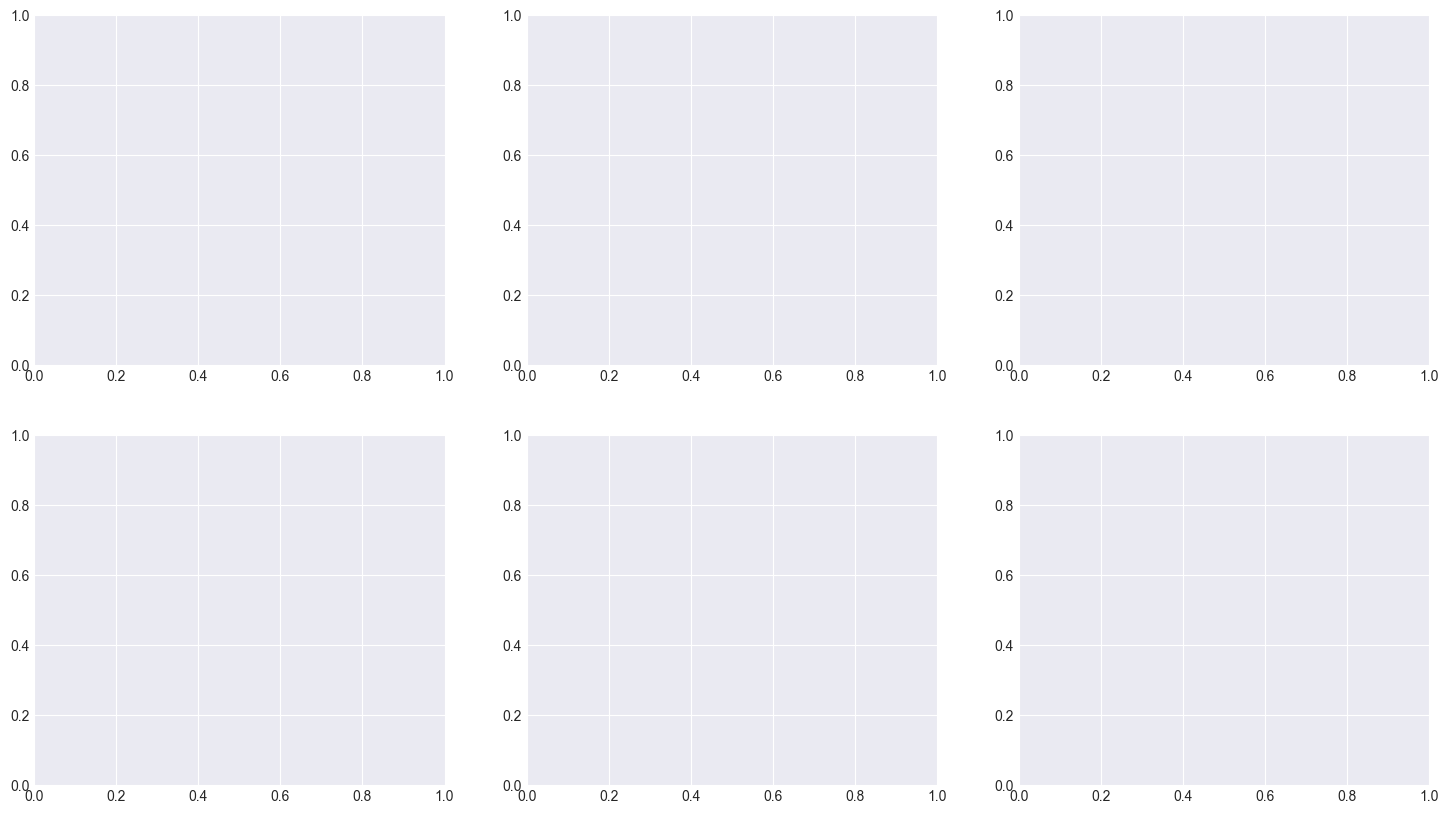

In [9]:
# Visualize Monte Carlo distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Ending equity distribution
eq_data = mc_result["raw_results"]["ending_equities"]
axes[0, 0].hist(eq_data, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 0].axvline(x=backtest["summary"]["ending_equity"], color='red', linestyle='--', linewidth=2, label='Baseline')
axes[0, 0].axvline(x=mc_result["summary"]["ending_equity"]["p50"], color='blue', linestyle='--', linewidth=2, label='MC Median')
axes[0, 0].set_title('Ending Equity Distribution')
axes[0, 0].set_xlabel('Ending Equity ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Max drawdown distribution
dd_data = mc_result["raw_results"]["max_drawdowns"]
axes[0, 1].hist(dd_data, bins=50, edgecolor='black', alpha=0.7, color='red')
axes[0, 1].axvline(x=backtest["summary"]["max_drawdown"], color='blue', linestyle='--', linewidth=2, label='Baseline')
axes[0, 1].axvline(x=mc_result["summary"]["max_drawdown"]["p50"], color='green', linestyle='--', linewidth=2, label='MC Median')
axes[0, 1].set_title('Max Drawdown Distribution')
axes[0, 1].set_xlabel('Max Drawdown ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Win rate distribution
wr_data = mc_result["raw_results"]["win_rates"]
axes[0, 2].hist(wr_data, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 2].axvline(x=backtest["summary"]["win_rate"], color='blue', linestyle='--', linewidth=2, label='Baseline')
axes[0, 2].axvline(x=mc_result["summary"]["win_rate"]["p50"], color='green', linestyle='--', linewidth=2, label='MC Median')
axes[0, 2].set_title('Win Rate Distribution')
axes[0, 2].set_xlabel('Win Rate')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Profit factor distribution (filter inf values)
pf_data = [x for x in mc_result["raw_results"]["profit_factors"] if x < 100]
axes[1, 0].hist(pf_data, bins=50, edgecolor='black', alpha=0.7, color='purple')
baseline_pf = backtest["summary"]["profit_factor"]
if baseline_pf != float('inf'):
    axes[1, 0].axvline(x=baseline_pf, color='blue', linestyle='--', linewidth=2, label='Baseline')
axes[1, 0].axvline(x=mc_result["summary"]["profit_factor"]["p50"], color='green', linestyle='--', linewidth=2, label='MC Median')
axes[1, 0].axvline(x=1.0, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Break-even')
axes[1, 0].set_title('Profit Factor Distribution')
axes[1, 0].set_xlabel('Profit Factor')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Net P&L distribution
pnl_data = mc_result["raw_results"]["net_pnls"]
axes[1, 1].hist(pnl_data, bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[1, 1].axvline(x=backtest["summary"]["net_pnl"], color='blue', linestyle='--', linewidth=2, label='Baseline')
axes[1, 1].axvline(x=mc_result["summary"]["net_pnl"]["p50"], color='green', linestyle='--', linewidth=2, label='MC Median')
axes[1, 1].axvline(x=0, color='red', linestyle=':', linewidth=1, alpha=0.5)
axes[1, 1].set_title('Net P&L Distribution')
axes[1, 1].set_xlabel('Net P&L ($)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Summary comparison
summary_metrics = {
    'Ending Equity': {
        'Baseline': backtest["summary"]["ending_equity"],
        'MC p05': mc_result["summary"]["ending_equity"]["p05"],
        'MC p50': mc_result["summary"]["ending_equity"]["p50"],
        'MC p95': mc_result["summary"]["ending_equity"]["p95"],
    },
    'Max Drawdown': {
        'Baseline': backtest["summary"]["max_drawdown"],
        'MC p05': mc_result["summary"]["max_drawdown"]["p05"],
        'MC p50': mc_result["summary"]["max_drawdown"]["p50"],
        'MC p95': mc_result["summary"]["max_drawdown"]["p95"],
    },
    'Win Rate': {
        'Baseline': backtest["summary"]["win_rate"],
        'MC p05': mc_result["summary"]["win_rate"]["p05"],
        'MC p50': mc_result["summary"]["win_rate"]["p50"],
        'MC p95': mc_result["summary"]["win_rate"]["p95"],
    },
}

summary_df = pd.DataFrame(summary_metrics)
axes[1, 2].axis('tight')
axes[1, 2].axis('off')
table = axes[1, 2].table(cellText=summary_df.values.round(2), 
                         rowLabels=summary_df.index,
                         colLabels=summary_df.columns,
                         cellLoc='center',
                         loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
axes[1, 2].set_title('Baseline vs Monte Carlo Percentiles')

plt.tight_layout()
plt.show()

# Print key insights
print("\n" + "="*60)
print("MONTE CARLO INSIGHTS")
print("="*60)
print(f"\nEnding Equity:")
print(f"  Baseline: ${backtest['summary']['ending_equity']:.2f}")
print(f"  MC Median (p50): ${mc_result['summary']['ending_equity']['p50']:.2f}")
print(f"  MC Range (p05-p95): ${mc_result['summary']['ending_equity']['p05']:.2f} - ${mc_result['summary']['ending_equity']['p95']:.2f}")

print(f"\nMax Drawdown:")
print(f"  Baseline: ${backtest['summary']['max_drawdown']:.2f}")
print(f"  MC Median (p50): ${mc_result['summary']['max_drawdown']['p50']:.2f}")
print(f"  MC Range (p05-p95): ${mc_result['summary']['max_drawdown']['p05']:.2f} - ${mc_result['summary']['max_drawdown']['p95']:.2f}")

print(f"\nWin Rate:")
print(f"  Baseline: {backtest['summary']['win_rate']:.2%}")
print(f"  MC Median (p50): {mc_result['summary']['win_rate']['p50']:.2%}")
print(f"  MC Range (p05-p95): {mc_result['summary']['win_rate']['p05']:.2%} - {mc_result['summary']['win_rate']['p95']:.2%}")

# Risk assessment
p95_dd = mc_result['summary']['max_drawdown']['p95']
p05_equity = mc_result['summary']['ending_equity']['p05']
print(f"\nRisk Assessment:")
print(f"  Worst case (p95) drawdown: ${p95_dd:.2f}")
print(f"  Worst case (p05) ending equity: ${p05_equity:.2f}")
if p05_equity < initial_equity * 0.8:
    print(f"  ⚠️  High risk: 5% chance of losing >20% of capital")
elif p05_equity < initial_equity:
    print(f"  ⚠️  Moderate risk: 5% chance of ending below starting equity")
else:
    print(f"  ✅ Low risk: Even worst case preserves capital")


## 5. Performance Analysis & Improvement Ideas

Analyze trade characteristics to identify improvement opportunities.


In [ ]:
# Detailed trade analysis
trades_df = pd.DataFrame(backtest["trades"])

if len(trades_df) > 0:
    # Add derived metrics
    trades_df["is_win"] = trades_df["pnl"] > 0
    trades_df["is_loss"] = trades_df["pnl"] < 0
    trades_df["abs_pnl"] = trades_df["pnl"].abs()
    
    # Time analysis
    trades_df["entry_time"] = pd.to_datetime(trades_df["entry_time"])
    trades_df["exit_time"] = pd.to_datetime(trades_df["exit_time"])
    trades_df["hold_time"] = trades_df["exit_time"] - trades_df["entry_time"]
    trades_df["entry_hour"] = trades_df["entry_time"].dt.hour
    trades_df["entry_day"] = trades_df["entry_time"].dt.day_name()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Win rate by direction
    wr_by_dir = trades_df.groupby("direction")["is_win"].mean()
    axes[0, 0].bar(wr_by_dir.index, wr_by_dir.values, color=['green', 'red'], alpha=0.7)
    axes[0, 0].axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
    axes[0, 0].set_title('Win Rate by Direction')
    axes[0, 0].set_ylabel('Win Rate')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Average P&L by direction
    avg_pnl_by_dir = trades_df.groupby("direction")["pnl"].mean()
    colors = ['green' if x > 0 else 'red' for x in avg_pnl_by_dir.values]
    axes[0, 1].bar(avg_pnl_by_dir.index, avg_pnl_by_dir.values, color=colors, alpha=0.7)
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[0, 1].set_title('Average P&L by Direction')
    axes[0, 1].set_ylabel('Avg P&L ($)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Win rate by entry hour
    wr_by_hour = trades_df.groupby("entry_hour")["is_win"].mean()
    axes[0, 2].plot(wr_by_hour.index, wr_by_hour.values, marker='o', linewidth=2, markersize=8)
    axes[0, 2].axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
    axes[0, 2].set_title('Win Rate by Entry Hour')
    axes[0, 2].set_xlabel('Hour of Day')
    axes[0, 2].set_ylabel('Win Rate')
    axes[0, 2].set_ylim(0, 1)
    axes[0, 2].grid(True, alpha=0.3)
    
    # P&L distribution by win/loss
    wins = trades_df[trades_df["is_win"]]["pnl"]
    losses = trades_df[trades_df["is_loss"]]["pnl"]
    axes[1, 0].hist([wins, losses], bins=30, label=['Wins', 'Losses'], alpha=0.7, color=['green', 'red'])
    axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1, 0].set_title('P&L Distribution: Wins vs Losses')
    axes[1, 0].set_xlabel('P&L ($)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Trade frequency by day of week
    trades_by_day = trades_df["entry_day"].value_counts()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    trades_by_day = trades_by_day.reindex([d for d in day_order if d in trades_by_day.index])
    axes[1, 1].bar(range(len(trades_by_day)), trades_by_day.values, alpha=0.7, color='blue')
    axes[1, 1].set_xticks(range(len(trades_by_day)))
    axes[1, 1].set_xticklabels(trades_by_day.index, rotation=45)
    axes[1, 1].set_title('Trade Frequency by Day of Week')
    axes[1, 1].set_ylabel('Number of Trades')
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Risk/Reward analysis
    avg_win = wins.mean() if len(wins) > 0 else 0
    avg_loss = abs(losses.mean()) if len(losses) > 0 else 1
    rr_ratio = avg_win / avg_loss if avg_loss > 0 else 0
    
    axes[1, 2].barh(['Avg Win', 'Avg Loss'], [avg_win, -avg_loss], color=['green', 'red'], alpha=0.7)
    axes[1, 2].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[1, 2].set_title(f'Average Win vs Loss\n(R:R Ratio = {rr_ratio:.2f})')
    axes[1, 2].set_xlabel('P&L ($)')
    axes[1, 2].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Print improvement suggestions
    print("\n" + "="*60)
    print("PERFORMANCE ANALYSIS & IMPROVEMENT SUGGESTIONS")
    print("="*60)
    
    print(f"\n1. Risk/Reward Analysis:")
    print(f"   Average Win: ${avg_win:.2f}")
    print(f"   Average Loss: ${avg_loss:.2f}")
    print(f"   Risk:Reward Ratio: {rr_ratio:.2f}")
    if rr_ratio < 1.0:
        print(f"   ⚠️  R:R < 1.0: Average loss exceeds average win - consider tighter stops or wider targets")
    elif rr_ratio < 1.5:
        print(f"   💡 R:R < 1.5: Could improve by increasing target size or reducing stop size")
    else:
        print(f"   ✅ Good R:R ratio")
    
    print(f"\n2. Direction Performance:")
    for direction in trades_df["direction"].unique():
        dir_trades = trades_df[trades_df["direction"] == direction]
        dir_wr = dir_trades["is_win"].mean()
        dir_avg_pnl = dir_trades["pnl"].mean()
        print(f"   {direction.upper()}: Win Rate={dir_wr:.2%}, Avg P&L=${dir_avg_pnl:.2f}")
        if dir_wr < 0.45:
            print(f"      ⚠️  Low win rate for {direction} - consider filtering or adjusting entry criteria")
    
    print(f"\n3. Time-based Patterns:")
    best_hour = wr_by_hour.idxmax()
    worst_hour = wr_by_hour.idxmin()
    print(f"   Best hour: {best_hour}:00 (WR={wr_by_hour[best_hour]:.2%})")
    print(f"   Worst hour: {worst_hour}:00 (WR={wr_by_hour[worst_hour]:.2%})")
    if wr_by_hour[worst_hour] < 0.4:
        print(f"      💡 Consider avoiding trades during {worst_hour}:00")
    
    print(f"\n4. Trade Frequency:")
    print(f"   Total trades: {len(trades_df)}")
    print(f"   Most active day: {trades_by_day.idxmax()} ({trades_by_day.max()} trades)")
    
    # Check for consistency
    wr_std = wr_by_hour.std() if len(wr_by_hour) > 1 else 0
    print(f"\n5. Consistency:")
    print(f"   Win rate std dev across hours: {wr_std:.3f}")
    if wr_std > 0.15:
        print(f"      ⚠️  High variance - strategy performance varies significantly by time")
    else:
        print(f"      ✅ Relatively consistent performance across time periods")



## 6. 3D Visualizations

Multi-dimensional analysis of strategy performance.


In [ ]:
# 3D Visualizations
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

if len(trades_df) > 0:
    fig = plt.figure(figsize=(20, 15))
    
    # 1. 3D Scatter: Entry Time vs P&L vs Contracts
    ax1 = fig.add_subplot(2, 3, 1, projection='3d')
    colors = ['green' if pnl > 0 else 'red' for pnl in trades_df['pnl']]
    scatter = ax1.scatter(
        trades_df['entry_hour'], 
        trades_df['contracts'], 
        trades_df['pnl'],
        c=colors, 
        alpha=0.6,
        s=50
    )
    ax1.set_xlabel('Entry Hour')
    ax1.set_ylabel('Contracts')
    ax1.set_zlabel('P&L ($)')
    ax1.set_title('3D: Hour vs Contracts vs P&L')
    
    # 2. 3D Bar Chart: Win Rate by Direction and Hour
    ax2 = fig.add_subplot(2, 3, 2, projection='3d')
    hours = sorted(trades_df['entry_hour'].unique())
    directions = ['long', 'short']
    xpos = []
    ypos = []
    zpos = []
    dx = []
    dy = []
    dz = []
    colors_bar = []
    
    for i, hour in enumerate(hours):
        for j, direction in enumerate(directions):
            mask = (trades_df['entry_hour'] == hour) & (trades_df['direction'] == direction)
            if mask.sum() > 0:
                wr = trades_df[mask]['is_win'].mean()
                xpos.append(i)
                ypos.append(j)
                zpos.append(0)
                dx.append(0.8)
                dy.append(0.8)
                dz.append(wr)
                colors_bar.append('green' if wr > 0.5 else 'red')
    
    if xpos:
        ax2.bar3d(xpos, ypos, zpos, dx, dy, dz, alpha=0.7, color=colors_bar)
        ax2.set_xticks(range(len(hours)))
        ax2.set_xticklabels(hours)
        ax2.set_yticks(range(len(directions)))
        ax2.set_yticklabels(directions)
        ax2.set_zlabel('Win Rate')
        ax2.set_title('Win Rate: Hour × Direction')
    
    # 3. 3D Surface: Performance Heatmap (if we have enough data points)
    ax3 = fig.add_subplot(2, 3, 3, projection='3d')
    if len(hours) > 2:
        hour_grid = []
        direction_grid = []
        pnl_grid = []
        
        for hour in hours:
            for direction in directions:
                mask = (trades_df['entry_hour'] == hour) & (trades_df['direction'] == direction)
                if mask.sum() > 0:
                    avg_pnl = trades_df[mask]['pnl'].mean()
                    hour_grid.append(hour)
                    direction_grid.append(1 if direction == 'long' else 0)
                    pnl_grid.append(avg_pnl)
        
        if len(hour_grid) > 4:
            # Create surface plot
            from scipy.interpolate import griddata
            import numpy as np
            
            xi = np.linspace(min(hour_grid), max(hour_grid), 20)
            yi = np.linspace(0, 1, 10)
            xi, yi = np.meshgrid(xi, yi)
            
            try:
                zi = griddata((hour_grid, direction_grid), pnl_grid, (xi, yi), method='cubic')
                surf = ax3.plot_surface(xi, yi, zi, cmap='RdYlGn', alpha=0.8, linewidth=0)
                ax3.set_xlabel('Entry Hour')
                ax3.set_ylabel('Direction (0=Short, 1=Long)')
                ax3.set_zlabel('Avg P&L ($)')
                ax3.set_title('Average P&L Surface')
                fig.colorbar(surf, ax=ax3, shrink=0.5)
            except:
                # Fallback to scatter if interpolation fails
                ax3.scatter(hour_grid, direction_grid, pnl_grid, c=pnl_grid, cmap='RdYlGn', s=100)
                ax3.set_xlabel('Entry Hour')
                ax3.set_ylabel('Direction')
                ax3.set_zlabel('Avg P&L ($)')
                ax3.set_title('Average P&L by Hour × Direction')
    
    # 4. 3D Line: Equity Curve Evolution
    ax4 = fig.add_subplot(2, 3, 4, projection='3d')
    if 'cumulative_pnl' not in trades_df.columns:
        trades_df['cumulative_pnl'] = trades_df['pnl'].cumsum()
    if 'trade_num' not in trades_df.columns:
        trades_df['trade_num'] = range(len(trades_df))
    
    equity_curve_3d = initial_equity + trades_df['cumulative_pnl'].values
    ax4.plot(trades_df['trade_num'], trades_df['entry_hour'], equity_curve_3d, linewidth=2)
    ax4.scatter(trades_df['trade_num'], trades_df['entry_hour'], equity_curve_3d, 
                c=trades_df['pnl'], cmap='RdYlGn', s=30, alpha=0.7)
    ax4.set_xlabel('Trade Number')
    ax4.set_ylabel('Entry Hour')
    ax4.set_zlabel('Equity ($)')
    ax4.set_title('Equity Curve: Trade # vs Hour')
    
    # 5. 3D Scatter: Risk/Reward Analysis
    ax5 = fig.add_subplot(2, 3, 5, projection='3d')
    # Calculate risk (stop distance) and reward (actual P&L)
    trades_df['risk_estimate'] = trades_df['stop_ticks'] * 1.25 * trades_df['contracts']  # Estimated risk
    trades_df['reward'] = trades_df['pnl']
    trades_df['rr_ratio'] = trades_df['reward'] / trades_df['risk_estimate'].abs().replace(0, 1)
    
    scatter_colors = ['green' if x > 1 else 'orange' if x > 0 else 'red' for x in trades_df['rr_ratio']]
    ax5.scatter(
        trades_df['contracts'],
        trades_df['risk_estimate'],
        trades_df['reward'],
        c=scatter_colors,
        alpha=0.6,
        s=50
    )
    ax5.set_xlabel('Contracts')
    ax5.set_ylabel('Estimated Risk ($)')
    ax5.set_zlabel('Actual Reward ($)')
    ax5.set_title('Risk/Reward: Contracts × Risk × Reward')
    
    # 6. 3D Histogram: P&L Distribution by Direction and Contracts
    ax6 = fig.add_subplot(2, 3, 6, projection='3d')
    
    # Create bins
    pnl_bins = np.linspace(trades_df['pnl'].min(), trades_df['pnl'].max(), 10)
    contract_bins = sorted(trades_df['contracts'].unique())
    
    for direction in directions:
        dir_trades = trades_df[trades_df['direction'] == direction]
        for contracts in contract_bins:
            contract_trades = dir_trades[dir_trades['contracts'] == contracts]
            if len(contract_trades) > 0:
                hist, _ = np.histogram(contract_trades['pnl'], bins=pnl_bins)
                xpos = np.array([direction == 'long'] * len(hist))
                ypos = np.array([contracts] * len(hist))
                zpos = np.zeros(len(hist))
                dx = 0.8 * np.ones(len(hist))
                dy = 0.3 * np.ones(len(hist))
                dz = hist.astype(float)
                
                color = 'green' if direction == 'long' else 'blue'
                ax6.bar3d(xpos, ypos, zpos, dx, dy, dz, alpha=0.6, color=color)
    
    ax6.set_xlabel('Direction (0=Short, 1=Long)')
    ax6.set_ylabel('Contracts')
    ax6.set_zlabel('Frequency')
    ax6.set_title('P&L Distribution: Direction × Contracts')
    
    plt.tight_layout()
    plt.show()
    
    print("3D visualizations complete!")


In [ ]:
# 3D Monte Carlo Equity Curve Comparison
fig = plt.figure(figsize=(16, 10))

# Plot multiple Monte Carlo equity curves in 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Sample 20 random equity curves from Monte Carlo results
if 'mc_result' in locals() and len(mc_result['raw_results']['ending_equities']) > 0:
    n_curves = min(20, len(mc_result['raw_results']['ending_equities']))
    indices = np.random.choice(len(mc_result['raw_results']['ending_equities']), n_curves, replace=False)
    
    # Simulate equity curves (we'll approximate using the P&L distribution)
    for idx in indices[:10]:  # Show first 10 for clarity
        # Generate a random sequence of trades
        sampled_pnl = np.random.choice(mc_result['raw_results']['net_pnls'], size=len(trades_df), replace=True)
        equity_curve = initial_equity + np.cumsum(sampled_pnl)
        
        # Plot in 3D with trade number and hour (approximate)
        trade_numbers = range(len(equity_curve))
        # Use entry hours if available, otherwise approximate
        if 'entry_hour' in trades_df.columns and len(trades_df) == len(equity_curve):
            hours = trades_df['entry_hour'].values
        else:
            hours = np.linspace(8, 15, len(equity_curve))
        
        ax1.plot(trade_numbers, hours, equity_curve, alpha=0.3, linewidth=1)
    
    # Plot baseline equity curve
    baseline_equity = initial_equity + trades_df['cumulative_pnl'].values
    if 'entry_hour' in trades_df.columns:
        baseline_hours = trades_df['entry_hour'].values
    else:
        baseline_hours = np.linspace(8, 15, len(baseline_equity))
    ax1.plot(range(len(baseline_equity)), baseline_hours, baseline_equity, 
             'r-', linewidth=3, label='Baseline', alpha=0.9)
    
    ax1.set_xlabel('Trade Number')
    ax1.set_ylabel('Entry Hour')
    ax1.set_zlabel('Equity ($)')
    ax1.set_title('Monte Carlo Equity Curves (3D)')
    ax1.legend()

# 3D Performance Landscape: Win Rate vs Profit Factor vs Max Drawdown
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Extract Monte Carlo results
if 'mc_result' in locals():
    wr_data = mc_result['raw_results']['win_rates']
    pf_data = mc_result['raw_results']['profit_factors']
    dd_data = mc_result['raw_results']['max_drawdowns']
    
    # Filter out infinite profit factors
    valid_mask = np.array([pf < 100 for pf in pf_data])
    wr_filtered = np.array(wr_data)[valid_mask]
    pf_filtered = np.array(pf_data)[valid_mask]
    dd_filtered = np.array(dd_data)[valid_mask]
    
    # Color by ending equity (better = greener)
    eq_filtered = np.array(mc_result['raw_results']['ending_equities'])[valid_mask]
    colors_3d = eq_filtered
    
    scatter = ax2.scatter(wr_filtered, pf_filtered, dd_filtered, 
                          c=colors_3d, cmap='RdYlGn', alpha=0.6, s=30)
    
    # Mark baseline
    baseline_wr = backtest['summary']['win_rate']
    baseline_pf = backtest['summary']['profit_factor'] if backtest['summary']['profit_factor'] != float('inf') else 10
    baseline_dd = backtest['summary']['max_drawdown']
    ax2.scatter([baseline_wr], [baseline_pf], [baseline_dd], 
                c='red', s=200, marker='*', edgecolors='black', linewidths=2, label='Baseline')
    
    ax2.set_xlabel('Win Rate')
    ax2.set_ylabel('Profit Factor')
    ax2.set_zlabel('Max Drawdown ($)')
    ax2.set_title('Performance Landscape (MC Trials)')
    fig.colorbar(scatter, ax=ax2, label='Ending Equity ($)')
    ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
# 3D Parameter Sensitivity Analysis (if you want to explore different configs)
# This cell shows how you could visualize performance across different parameter combinations

fig = plt.figure(figsize=(18, 6))

# Example: If you were to test different stop_loss_ticks and target_multiplier combinations
# This is a template - adjust based on what parameters you want to analyze

ax = fig.add_subplot(1, 3, 1, projection='3d')

# Create example parameter grid (you would run multiple backtests with different params)
# For now, we'll use the current backtest and show the structure

print("3D Parameter Space Analysis Template")
print("="*60)
print("To use this effectively, run backtests with different parameter combinations")
print("and collect the results. Then plot them in 3D space.")
print("\nExample dimensions to explore:")
print("  - Stop Loss Ticks vs Target Multiplier vs Win Rate")
print("  - Min Probability Threshold vs Contracts vs Profit Factor")
print("  - Max Hold Bars vs Stop Ticks vs Ending Equity")

# Create a conceptual visualization using the current data
if len(trades_df) > 0:
    # Use actual data to show structure
    stop_ticks_unique = sorted(trades_df['stop_ticks'].unique())
    contracts_unique = sorted(trades_df['contracts'].unique())
    
    # Calculate average metrics for each combination
    z_data = []
    x_data = []
    y_data = []
    
    for stop_ticks in stop_ticks_unique[:5]:  # Limit for clarity
        for contracts in contracts_unique:
            mask = (trades_df['stop_ticks'] == stop_ticks) & (trades_df['contracts'] == contracts)
            if mask.sum() > 0:
                avg_pnl = trades_df[mask]['pnl'].mean()
                x_data.append(stop_ticks)
                y_data.append(contracts)
                z_data.append(avg_pnl)
    
    if x_data:
        scatter = ax.scatter(x_data, y_data, z_data, c=z_data, cmap='RdYlGn', s=100, alpha=0.7)
        ax.set_xlabel('Stop Ticks')
        ax.set_ylabel('Contracts')
        ax.set_zlabel('Avg P&L ($)')
        ax.set_title('Performance: Stop Ticks × Contracts')
        fig.colorbar(scatter, ax=ax, label='Avg P&L ($)')

# 3D Trade Sequence Analysis
ax2 = fig.add_subplot(1, 3, 2, projection='3d')

# Plot trade sequence showing win/loss pattern
trades_df['trade_sequence'] = range(len(trades_df))
trades_df['cumulative_pnl_3d'] = trades_df['pnl'].cumsum()

# Color by win/loss
colors_seq = ['green' if pnl > 0 else 'red' for pnl in trades_df['pnl']]
ax2.scatter(trades_df['trade_sequence'], 
            trades_df['entry_hour'], 
            trades_df['cumulative_pnl_3d'],
            c=colors_seq, alpha=0.7, s=50)

# Draw lines connecting consecutive trades
for i in range(len(trades_df) - 1):
    ax2.plot([trades_df.iloc[i]['trade_sequence'], trades_df.iloc[i+1]['trade_sequence']],
             [trades_df.iloc[i]['entry_hour'], trades_df.iloc[i+1]['entry_hour']],
             [trades_df.iloc[i]['cumulative_pnl_3d'], trades_df.iloc[i+1]['cumulative_pnl_3d']],
             color='gray', alpha=0.3, linewidth=1)

ax2.set_xlabel('Trade Sequence')
ax2.set_ylabel('Entry Hour')
ax2.set_zlabel('Cumulative P&L ($)')
ax2.set_title('Trade Sequence Path (3D)')

# 3D Performance Metrics Comparison
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# Compare different performance metrics
metrics_data = {
    'Win Rate': backtest['summary']['win_rate'],
    'Profit Factor': min(backtest['summary']['profit_factor'], 10) if backtest['summary']['profit_factor'] != float('inf') else 10,
    'Ending Equity (norm)': (backtest['summary']['ending_equity'] - initial_equity) / initial_equity * 100,
    'Max DD (norm)': backtest['summary']['max_drawdown'] / initial_equity * 100,
}

# Create a 3D bar showing key metrics
if 'mc_result' in locals():
    # Show baseline vs MC median
    x_labels = ['Baseline', 'MC Median']
    metrics_3d = {
        'Win Rate': [backtest['summary']['win_rate'], mc_result['summary']['win_rate']['p50']],
        'Profit Factor': [
            min(backtest['summary']['profit_factor'], 10) if backtest['summary']['profit_factor'] != float('inf') else 10,
            mc_result['summary']['profit_factor']['p50']
        ],
        'Max DD %': [
            backtest['summary']['max_drawdown'] / initial_equity * 100,
            mc_result['summary']['max_drawdown']['p50'] / initial_equity * 100
        ]
    }
    
    xpos = [0, 1]
    ypos = [0, 1, 2]
    zpos = [0, 0, 0, 0, 0, 0]
    dx = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8]
    dy = [0.8, 0.8, 0.8, 0.8, 0.8, 0.8]
    dz = [metrics_3d['Win Rate'][0], metrics_3d['Win Rate'][1],
          metrics_3d['Profit Factor'][0], metrics_3d['Profit Factor'][1],
          metrics_3d['Max DD %'][0], metrics_3d['Max DD %'][1]]
    
    colors_metrics = ['blue', 'green', 'orange', 'yellow', 'red', 'pink']
    ax3.bar3d([0, 1, 0, 1, 0, 1], [0, 0, 1, 1, 2, 2], zpos, dx, dy, dz, 
              color=colors_metrics, alpha=0.7)
    ax3.set_xticks([0, 1])
    ax3.set_xticklabels(['Baseline', 'MC Median'])
    ax3.set_yticks([0, 1, 2])
    ax3.set_yticklabels(['Win Rate', 'Profit Factor', 'Max DD %'])
    ax3.set_zlabel('Value')
    ax3.set_title('Metrics Comparison: Baseline vs MC')

plt.tight_layout()
plt.show()


In [ ]:
# Visualize backtest results
trades_df = pd.DataFrame(backtest["trades"])

if len(trades_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Equity curve
    trades_df["cumulative_pnl"] = trades_df["pnl"].cumsum()
    starting_balance = backtest["summary"]["starting_balance"]
    equity_curve = starting_balance + trades_df["cumulative_pnl"]
    
    axes[0, 0].plot(range(len(equity_curve)), equity_curve, linewidth=2)
    axes[0, 0].axhline(y=starting_balance, color='black', linestyle='--', alpha=0.5, label='Starting Balance')
    axes[0, 0].set_title('Equity Curve')
    axes[0, 0].set_xlabel('Trade Number')
    axes[0, 0].set_ylabel('Equity ($)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Drawdown
    peaks = equity_curve.expanding().max()
    drawdown = (equity_curve - peaks) / peaks * 100
    axes[0, 1].fill_between(range(len(drawdown)), drawdown, 0, alpha=0.5, color='red')
    axes[0, 1].set_title('Drawdown %')
    axes[0, 1].set_xlabel('Trade Number')
    axes[0, 1].set_ylabel('Drawdown (%)')
    axes[0, 1].grid(True, alpha=0.3)
    
    # P&L distribution
    axes[1, 0].hist(trades_df["pnl"], bins=30, edgecolor='black', alpha=0.7)
    axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5)
    axes[1, 0].set_title('P&L Distribution')
    axes[1, 0].set_xlabel('P&L ($)')
    axes[1, 0].set_ylabel('Frequency')
    
    # Win/Loss by direction
    win_loss = trades_df.groupby(["direction", (trades_df["pnl"] > 0)]).size().unstack(fill_value=0)
    win_loss.plot(kind='bar', ax=axes[1, 1], color=['red', 'green'], alpha=0.7)
    axes[1, 1].set_title('Wins vs Losses by Direction')
    axes[1, 1].set_xlabel('Direction')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].legend(['Loss', 'Win'])
    axes[1, 1].tick_params(axis='x', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Trade statistics
    print("\nTrade Statistics:")
    print(f"Total trades: {len(trades_df)}")
    print(f"Winning trades: {(trades_df['pnl'] > 0).sum()}")
    print(f"Losing trades: {(trades_df['pnl'] < 0).sum()}")
    print(f"Average win: ${trades_df[trades_df['pnl'] > 0]['pnl'].mean():.2f}")
    print(f"Average loss: ${trades_df[trades_df['pnl'] < 0]['pnl'].mean():.2f}")
    print(f"Largest win: ${trades_df['pnl'].max():.2f}")
    print(f"Largest loss: ${trades_df['pnl'].min():.2f}")


## 7. Overfitting Detection & Model Diagnostics

Analyze model performance across train/validation/test splits to detect overfitting and diagnose model issues.


In [ ]:
# Overfitting / Reality-check diagnostics
print('='*60)
print('DIAGNOSTICS: TRAIN/VAL/TEST vs TRADE-IDENTICAL BACKTEST')
print('='*60)

if 'results' not in locals():
    raise RuntimeError('Run the training cell first.')

metrics = results.get('metrics', {})
backtest_metrics = results.get('backtest_metrics', {})

print('
1) Classification metrics (train/val/test) on the label dataset:')
for direction in ['long', 'short']:
    if direction not in metrics:
        continue
    print(f"
{direction.upper()} model")
    for split in ['training', 'validation', 'test']:
        m = metrics[direction].get(split, {})
        if not m:
            continue
        print(
            f"  {split:10s} "
            f"acc={m.get('accuracy', 0):.3f} auc={m.get('roc_auc', 0):.3f} "
            f"label_trades@thr={m.get('trades', 0)} wr={m.get('win_rate', 0):.3f} pf={m.get('profit_factor', 0):.2f}"
        )

print('
2) Trade-identical backtest summaries by bar-split (this is the KPI):')
summaries = {}
for split_name, split_res in (backtest_metrics or {}).items():
    summaries[split_name] = (split_res or {}).get('summary', {})
display(JSON(summaries, indent=2))

print('
3) Tuned policy (selected on validation):')
display(JSON(results.get('policy', {}), indent=2))

test_summary = summaries.get('test', {}) or {}
if int(test_summary.get('trades', 0) or 0) == 0:
    print('
NOTE: Policy stood down (0 trades) on test -> no robust validation edge under current constraints.')


In [ ]:
# Visualize overfitting indicators
if 'results' in locals() and 'metrics' in results:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    metrics = results['metrics']
    directions = ['long', 'short']
    x = np.arange(len(directions))
    width = 0.25
    
    # 1. Accuracy comparison
    ax = axes[0, 0]
    train_acc = [metrics[d].get('training', {}).get('accuracy', 0) for d in directions]
    val_acc = [metrics[d].get('validation', {}).get('accuracy', 0) for d in directions]
    test_acc = [metrics[d].get('test', {}).get('accuracy', 0) for d in directions]
    
    ax.bar(x - width, train_acc, width, label='Training', alpha=0.7, color='green')
    ax.bar(x, val_acc, width, label='Validation', alpha=0.7, color='blue')
    ax.bar(x + width, test_acc, width, label='Test', alpha=0.7, color='orange')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy: Train vs Val vs Test (Overfitting Check)')
    ax.set_xticks(x)
    ax.set_xticklabels(directions)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
    
    # Add gap annotations
    for i, d in enumerate(directions):
        if train_acc[i] > 0:
            gap = train_acc[i] - val_acc[i]
            if gap > 0.05:
                ax.annotate(f'T-V: {gap:.3f}', xy=(i-width/2, train_acc[i]), 
                           ha='center', color='red', fontweight='bold', fontsize=8)
            gap2 = val_acc[i] - test_acc[i]
            if gap2 > 0.05:
                ax.annotate(f'V-T: {gap2:.3f}', xy=(i+width/2, val_acc[i]), 
                           ha='center', color='red', fontweight='bold', fontsize=8)
    
    # 2. ROC-AUC comparison
    ax = axes[0, 1]
    train_auc = [metrics[d].get('training', {}).get('roc_auc', 0) for d in directions]
    val_auc = [metrics[d].get('validation', {}).get('roc_auc', 0) for d in directions]
    test_auc = [metrics[d].get('test', {}).get('roc_auc', 0) for d in directions]
    
    ax.bar(x - width, train_auc, width, label='Training', alpha=0.7, color='green')
    ax.bar(x, val_auc, width, label='Validation', alpha=0.7, color='blue')
    ax.bar(x + width, test_auc, width, label='Test', alpha=0.7, color='orange')
    ax.set_ylabel('ROC-AUC')
    ax.set_title('ROC-AUC: Train vs Val vs Test')
    ax.set_xticks(x)
    ax.set_xticklabels(directions)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
    
    for i, d in enumerate(directions):
        if train_auc[i] > 0:
            gap = train_auc[i] - val_auc[i]
            if gap > 0.05:
                ax.annotate(f'T-V: {gap:.3f}', xy=(i-width/2, train_auc[i]), 
                           ha='center', color='red', fontweight='bold', fontsize=8)
            gap2 = val_auc[i] - test_auc[i]
            if gap2 > 0.05:
                ax.annotate(f'V-T: {gap2:.3f}', xy=(i+width/2, val_auc[i]), 
                           ha='center', color='red', fontweight='bold', fontsize=8)
    
    # 3. Win Rate comparison
    ax = axes[1, 0]
    train_wr = [metrics[d].get('training', {}).get('win_rate', 0) for d in directions]
    val_wr = [metrics[d].get('validation', {}).get('win_rate', 0) for d in directions]
    test_wr = [metrics[d].get('test', {}).get('win_rate', 0) for d in directions]
    
    ax.bar(x - width, train_wr, width, label='Training', alpha=0.7, color='green')
    ax.bar(x, val_wr, width, label='Validation', alpha=0.7, color='blue')
    ax.bar(x + width, test_wr, width, label='Test', alpha=0.7, color='orange')
    ax.set_ylabel('Win Rate')
    ax.set_title('Win Rate: Train vs Val vs Test')
    ax.set_xticks(x)
    ax.set_xticklabels(directions)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1)
    
    for i, d in enumerate(directions):
        if train_wr[i] > 0:
            gap = train_wr[i] - val_wr[i]
            if gap > 0.05:
                ax.annotate(f'T-V: {gap:.3f}', xy=(i-width/2, train_wr[i]), 
                           ha='center', color='red', fontweight='bold', fontsize=8)
            gap2 = val_wr[i] - test_wr[i]
            if gap2 > 0.05:
                ax.annotate(f'V-T: {gap2:.3f}', xy=(i+width/2, val_wr[i]), 
                           ha='center', color='red', fontweight='bold', fontsize=8)
    
    # 4. Profit Factor comparison
    ax = axes[1, 1]
    train_pf = [min(metrics[d].get('training', {}).get('profit_factor', 0), 10) for d in directions]
    val_pf = [min(metrics[d].get('validation', {}).get('profit_factor', 0), 10) for d in directions]
    test_pf = [min(metrics[d].get('test', {}).get('profit_factor', 0), 10) for d in directions]
    
    ax.bar(x - width, train_pf, width, label='Training', alpha=0.7, color='green')
    ax.bar(x, val_pf, width, label='Validation', alpha=0.7, color='blue')
    ax.bar(x + width, test_pf, width, label='Test', alpha=0.7, color='orange')
    ax.set_ylabel('Profit Factor')
    ax.set_title('Profit Factor: Train vs Val vs Test')
    ax.set_xticks(x)
    ax.set_xticklabels(directions)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Break-even')
    
    for i, d in enumerate(directions):
        if train_pf[i] > 0:
            gap = train_pf[i] - val_pf[i]
            if gap > 0.3:
                ax.annotate(f'T-V: {gap:.2f}', xy=(i-width/2, train_pf[i]), 
                           ha='center', color='red', fontweight='bold', fontsize=8)
            gap2 = val_pf[i] - test_pf[i]
            if gap2 > 0.3:
                ax.annotate(f'V-T: {gap2:.2f}', xy=(i+width/2, val_pf[i]), 
                           ha='center', color='red', fontweight='bold', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Summary assessment
    print("\n" + "="*60)
    print("OVERFITTING ASSESSMENT")
    print("="*60)
    
    overfitting_signs = []
    for direction in directions:
        train_acc = metrics[direction].get('training', {}).get('accuracy', 0)
        val_acc = metrics[direction].get('validation', {}).get('accuracy', 0)
        test_acc = metrics[direction].get('test', {}).get('accuracy', 0)
        
        train_val_gap = train_acc - val_acc if train_acc > 0 else 0
        val_test_gap = val_acc - test_acc if val_acc > 0 else 0
        
        print(f"\n{direction.upper()} Model:")
        if train_val_gap > 0.05:
            overfitting_signs.append(f"{direction}: Train-Val accuracy gap {train_val_gap:.3f}")
        if val_test_gap > 0.05:
            overfitting_signs.append(f"{direction}: Val-Test accuracy gap {val_test_gap:.3f}")
    
    if overfitting_signs:
        print("\n⚠️  OVERFITTING DETECTED:")
        for sign in overfitting_signs:
            print(f"   - {sign}")
        print("\n   Recommendations:")
        print("   • Reduce model complexity (lower max_depth, increase min_samples_leaf)")
        print("   • Add more regularization")
        print("   • Increase training data")
        print("   • Use feature selection to reduce dimensionality")
        print("   • Try simpler models (fewer trees, shallower trees)")
    else:
        print("\n✅ No significant overfitting detected between train and validation sets")
        print("   However, the gap between test metrics and actual backtest suggests:")
        print("   • Possible distribution shift")
        print("   • Issues with walk-forward validation")
        print("   • Need to investigate further")


In [ ]:
# Feature Importance Analysis
# High variance in feature importance can indicate overfitting

if 'results' in locals() and 'long_model' in results:
    print("\n" + "="*60)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*60)
    
    long_model = results['long_model']
    short_model = results['short_model']
    feature_cols = results['feature_cols']
    
    # Get feature importances
    long_importances = long_model.feature_importances_
    short_importances = short_model.feature_importances_
    
    # Create DataFrame for easier analysis
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'long_importance': long_importances,
        'short_importance': short_importances,
    })
    importance_df['avg_importance'] = (importance_df['long_importance'] + importance_df['short_importance']) / 2
    importance_df = importance_df.sort_values('avg_importance', ascending=False)
    
    # Plot top features
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Top 20 features
    top_n = 20
    top_features = importance_df.head(top_n)
    
    axes[0].barh(range(len(top_features)), top_features['avg_importance'], alpha=0.7)
    axes[0].set_yticks(range(len(top_features)))
    axes[0].set_yticklabels(top_features['feature'], fontsize=9)
    axes[0].set_xlabel('Average Importance')
    axes[0].set_title(f'Top {top_n} Features by Importance')
    axes[0].invert_yaxis()
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Feature importance distribution
    axes[1].hist(importance_df['avg_importance'], bins=30, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Feature Importance')
    axes[1].set_ylabel('Number of Features')
    axes[1].set_title('Feature Importance Distribution')
    axes[1].axvline(x=importance_df['avg_importance'].mean(), color='red', 
                    linestyle='--', linewidth=2, label=f'Mean: {importance_df["avg_importance"].mean():.4f}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Check for overfitting indicators in feature importance
    print("\nFeature Importance Analysis:")
    print(f"   Total features: {len(feature_cols)}")
    print(f"   Mean importance: {importance_df['avg_importance'].mean():.4f}")
    print(f"   Std dev: {importance_df['avg_importance'].std():.4f}")
    print(f"   Top 10 features account for: {importance_df.head(10)['avg_importance'].sum()*100:.1f}% of importance")
    
    # Check for many low-importance features (potential overfitting)
    low_importance = (importance_df['avg_importance'] < 0.01).sum()
    if low_importance > len(feature_cols) * 0.5:
        print(f"\n   ⚠️  {low_importance} features have <1% importance")
        print("      Consider feature selection to reduce noise")
    
    # Check for very high importance on few features (potential overfitting)
    top_5_pct = importance_df.head(5)['avg_importance'].sum()
    if top_5_pct > 0.7:
        print(f"\n   ⚠️  Top 5 features account for {top_5_pct*100:.1f}% of importance")
        print("      Model may be over-relying on few features")
    
    print("\n   Top 10 Most Important Features:")
    for idx, row in importance_df.head(10).iterrows():
        print(f"      {row['feature']:30s}: {row['avg_importance']:.4f}")


## How to Fix Overfitting (if detected)

If overfitting is detected, here are actionable steps:


In [ ]:
# Next experiments (prioritized)
print('='*60)
print('NEXT EXPERIMENTS (PRIORITIZED)')
print('='*60)

print(f"Current notebook config: label_mode={TRAINING_CONFIG.label_mode}, stop={TRAINING_CONFIG.stop_loss_ticks}, target_mult={TRAINING_CONFIG.target_multiplier}, max_hold={TRAINING_CONFIG.max_hold_bars}")

print('''1) Re-run on multiple windows (walk-forward folds)
   - The current train/val/test split is only one sample of regime behavior.
   - Add 3-5 rolling folds and require consistent validation profitability before going live.

2) Re-check stop/target/hold under REAL execution
   - Use `analysis/optimize_stops.py` to sanity-check whether the label EV is positive.
   - Then re-train with those parameters and validate via trade-identical backtest.

3) Threshold calibration
   - Treat the model probability as a score, not a calibrated probability.
   - Optimize threshold on validation for `net_pnl - λ*max_drawdown` with a minimum trade count.

4) Gating and regime filters
   - Time filters (avoid lunch / low-liquidity), ATR band, and trend alignment are already supported.
   - Expand the candidate gates carefully and require stability (not one lucky segment).

5) Model alternatives (if RF stays unstable)
   - Try `HistGradientBoostingClassifier` or similar and compare under the same backtest.
''')
